In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.basemap import Basemap

import xarray as xr
import pandas as pd
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors

from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap
from scipy.optimize import curve_fit
from datetime import datetime

In [2]:
# ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc').squeeze()
# ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc').squeeze()


ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Luke_Comments/model_uncertainty/pH_org_ensemblemean_585.nc').squeeze()

# ds3 = xr.open_dataset('pH_CMIP6_ens_running_mean_harmonic.nc').squeeze()
ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/Biascorrected_files/IPSL/pH_Biascorrected_ssp585_ensemblemean.nc').squeeze()




In [3]:
lat_range = slice(-30, 30)
lon_range = slice(30, 120)

month_hist_ds1  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
# month_FF_ds1  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2070', '2100')).groupby('time.month').mean()
month_FF_ds1  = ds1.sel(lat=lat_range, lon=lon_range, time= '2015').groupby('time.month').mean()



month_hist_ds2  = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
# month_FF_ds2  = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2070', '2100')).groupby('time.month').mean()
month_FF_ds2  = ds2.sel(lat=lat_range, lon=lon_range, time='2015').groupby('time.month').mean()


In [4]:
# annual_ds1 = month_hist_ds1.mean('month')
# annual_ds2 = month_FF_ds1.mean('month')
# annual_ds3 = month_hist_ds2.mean('month')
# annual_ds4 = month_FF_ds2.mean('month')


# seasonal_hist_ds1 = month_hist_ds1 - annual_ds1
# seasonal_FF_ds1 = month_FF_ds1 - annual_ds2
# seasonal_hist_ds2 = month_hist_ds2 - annual_ds3
# seasonal_FF_ds2 = month_FF_ds2 - annual_ds4

In [5]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

as_hist_ds1  = month_hist_ds1.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_hist_ds1  = month_hist_ds1.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_hist_ds1  = month_hist_ds1.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_hist_ds1  = month_hist_ds1.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_FF_ds1  = month_FF_ds1.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_FF_ds1  = month_FF_ds1.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_FF_ds1  = month_FF_ds1.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_FF_ds1  = month_FF_ds1.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_hist_ds2  = month_hist_ds2.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_hist_ds2  = month_hist_ds2.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_hist_ds2  = month_hist_ds2.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_hist_ds2  = month_hist_ds2.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_FF_ds2  = month_FF_ds2.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_FF_ds2  = month_FF_ds2.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_FF_ds2  = month_FF_ds2.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_FF_ds2  = month_FF_ds2.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])


In [6]:
as_hist_ds2.ph.values

array([8.0683791 , 8.06980254, 8.06729108, 8.06000188, 8.06057745,
       8.06659913, 8.06150929, 8.05367563, 8.05745365, 8.06389322,
       8.06629029, 8.06788476])

In [19]:
 8.06980254-8.05367563

0.016126909999998773

In [17]:
as_FF_ds2.ph.values

array([7.75646943, 7.755894  , 7.75146165, 7.74478499, 7.7459515 ,
       7.75195657, 7.74808819, 7.74016972, 7.74458054, 7.75107634,
       7.7535199 , 7.75414271])

In [18]:
7.75646943-7.74016972

0.01629971000000019

In [13]:
as_hist_ds2_max.ph.values

array(8.06980254)

In [20]:
bob_hist_ds2.ph.values

array([8.0789892 , 8.08034382, 8.07090174, 8.0614885 , 8.06350275,
       8.06677581, 8.07057767, 8.07406437, 8.0754832 , 8.07434151,
       8.07393994, 8.07228274])

In [22]:
8.08034382- 8.0614885

0.01885532000000012

In [21]:
bob_FF_ds2.ph.values

array([7.75240781, 7.75078543, 7.73883873, 7.7311128 , 7.73476434,
       7.73858017, 7.74420069, 7.74692665, 7.7490529 , 7.74890015,
       7.74764689, 7.74387089])

In [23]:
7.75240781-7.7311128

0.021295010000000225

In [7]:
as_hist_ds1_max  = as_hist_ds1.ph.max(dim='month')
as_FF_ds1_max  = as_FF_ds1.ph.max(dim='month')
as_hist_ds2_max  = as_hist_ds2.ph.max(dim='month')
as_FF_ds2_max  = as_FF_ds2.ph.max(dim='month')

bob_hist_ds1_max  = bob_hist_ds1.ph.max(dim='month')
bob_FF_ds1_max  = bob_FF_ds1.ph.max(dim='month')
bob_hist_ds2_max  = bob_hist_ds2.ph.max(dim='month')
bob_FF_ds2_max  = bob_FF_ds2.ph.max(dim='month')

cio_hist_ds1_max  = cio_hist_ds1.ph.max(dim='month')
cio_FF_ds1_max  = cio_FF_ds1.ph.max(dim='month')
cio_hist_ds2_max  = cio_hist_ds2.ph.max(dim='month')
cio_FF_ds2_max  = cio_FF_ds2.ph.max(dim='month')

sio_hist_ds1_max  = sio_hist_ds1.ph.max(dim='month')
sio_FF_ds1_max  = sio_FF_ds1.ph.max(dim='month')
sio_hist_ds2_max  = sio_hist_ds2.ph.max(dim='month')
sio_FF_ds2_max  = sio_FF_ds2.ph.max(dim='month')


In [9]:
as_FF_ds2_max

<xarray.DataArray 'ph' ()> Size: 8B
array(8.04589911)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [8]:
as_hist_ds1_min  = as_hist_ds1.ph.min(dim='month')
as_FF_ds1_min  = as_FF_ds1.ph.min(dim='month')
as_hist_ds2_min  = as_hist_ds2.ph.min(dim='month')
as_FF_ds2_min  = as_FF_ds2.ph.min(dim='month')

bob_hist_ds1_min  = bob_hist_ds1.ph.min(dim='month')
bob_FF_ds1_min  = bob_FF_ds1.ph.min(dim='month')
bob_hist_ds2_min  = bob_hist_ds2.ph.min(dim='month')
bob_FF_ds2_min  = bob_FF_ds2.ph.min(dim='month')

cio_hist_ds1_min  = cio_hist_ds1.ph.min(dim='month')
cio_FF_ds1_min  = cio_FF_ds1.ph.min(dim='month')
cio_hist_ds2_min  = cio_hist_ds2.ph.min(dim='month')
cio_FF_ds2_min  = cio_FF_ds2.ph.min(dim='month')

sio_hist_ds1_min  = sio_hist_ds1.ph.min(dim='month')
sio_FF_ds1_min  = sio_FF_ds1.ph.min(dim='month')
sio_hist_ds2_min  = sio_hist_ds2.ph.min(dim='month')
sio_FF_ds2_min  = sio_FF_ds2.ph.min(dim='month')

In [11]:
as_FF_ds2_min#.ph.values

<xarray.DataArray 'ph' ()> Size: 8B
array(8.02806432)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [9]:
bob_hist_ds1_min

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 8.051

In [10]:
sio_hist_ds1_max


<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 8.123

In [11]:
sio_FF_ds1_max

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 7.771

In [12]:
sio_hist_ds2_max

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 8.126

In [13]:
sio_FF_ds2_max

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 7.776

In [12]:
# sio_cmip6_hist_amp = amp
# sio_cmip6_FF_amp = 7.77-7.73 

sio_bem_hist_amp =sio_hist_ds2_max-sio_hist_ds2_min
sio_bem_FF_amp = sio_FF_ds2_max-sio_FF_ds2_min


# cio_cmip6_hist_amp = 8.08-8.06
# cio_cmip6_FF_amp = 7.75-7.73

cio_bem_hist_amp = cio_hist_ds2_max-cio_hist_ds2_min
cio_bem_FF_amp = cio_FF_ds2_max-cio_FF_ds2_min

# bob_cmip6_hist_amp = 8.08-8.05
# bob_cmip6_FF_amp = 7.75-7.72

bob_bem_hist_amp = bob_hist_ds2_max-bob_hist_ds2_min
bob_bem_FF_amp = bob_FF_ds2_max-bob_FF_ds2_min

# as_cmip6_hist_amp = 8.08-8.05
# as_cmip6_FF_amp = 7.76-7.73

as_bem_hist_amp = as_hist_ds2_max-as_hist_ds2_min
as_bem_FF_amp = as_FF_ds2_max-as_FF_ds2_min

# sio_cmip6_amp# = sio_FF_ds1_max - sio_hist_ds1_max
# sio_bem_amp# = sio_FF_ds2_max - sio_hist_ds2_max

# cio_cmip6_amp# = cio_FF_ds1_max - cio_hist_ds1_max
# cio_bem_amp# = cio_FF_ds2_max - cio_hist_ds2_max


# bob_cmip6_amp# = bob_FF_ds1_max - bob_hist_ds1_max
# bob_bem_amp# = bob_FF_ds2_max - bob_hist_ds2_max


# as_cmip6_amp# = as_FF_ds1_max - as_hist_ds1_max
# as_bem_amp# = as_FF_ds2_max - as_hist_ds2_max
##

In [13]:
as_bem_FF_amp 


<xarray.DataArray 'ph' ()> Size: 8B
array(0.01783479)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [14]:
# sio_cmip6_amp = sio_cmip6_FF_amp - sio_cmip6_hist_amp
sio_bem_amp = sio_bem_FF_amp - sio_bem_hist_amp

# cio_cmip6_amp = cio_cmip6_FF_amp - cio_cmip6_hist_amp
cio_bem_amp = cio_bem_FF_amp - cio_bem_hist_amp

# bob_cmip6_amp = bob_cmip6_FF_amp - bob_cmip6_hist_amp
bob_bem_amp = bob_bem_FF_amp - bob_bem_hist_amp

# as_cmip6_amp = as_cmip6_FF_amp - as_cmip6_hist_amp
as_bem_amp = as_bem_FF_amp - as_bem_hist_amp

In [18]:
as_bem_amp# = round(as_bem_amp, 2)

<xarray.DataArray 'ph' ()> Size: 8B
array(0.00170788)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [56]:
0.01629971-0.01612691

0.00017279999999999726

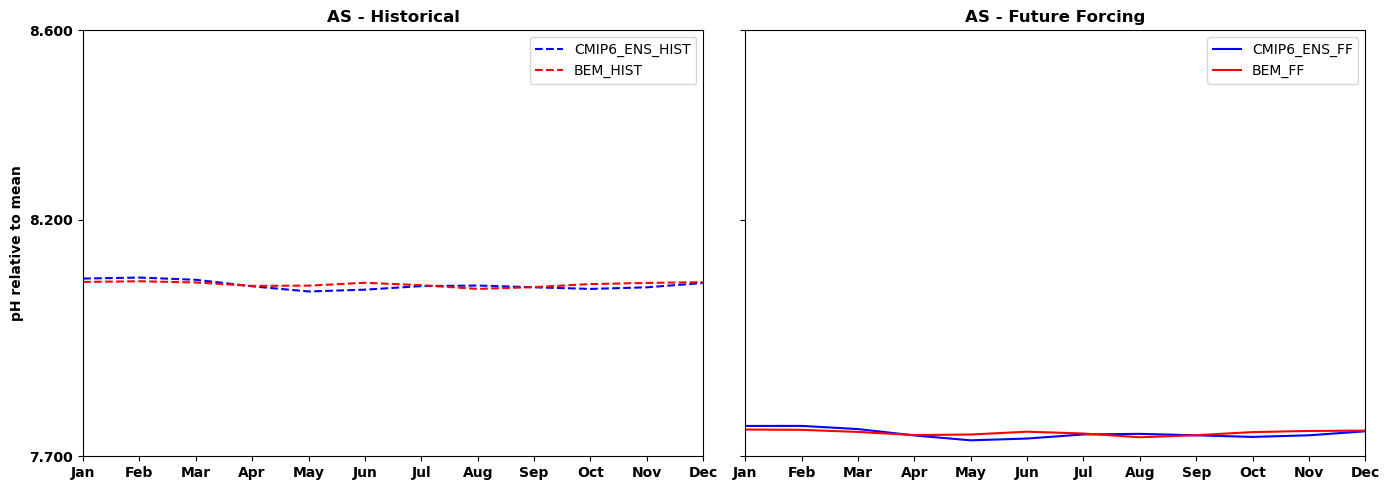

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Extract 'ph' variable from each dataset
# as_hist_ds1 = as_hist_ds1['ph']
# as_FF_ds1 = as_FF_ds1['ph']
# as_hist_ds2 = as_hist_ds2['ph']
# as_FF_ds2 = as_FF_ds2['ph']

# Time axis: 0 to 11 months
months = np.arange(12)

# X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Y-axis ticks
yticks = [7.70, 8.20, 8.60]

# ======= Combined Plot with 2 Subplots (side by side) =======
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), sharey=True)

# --- Plot 1: Historical ---
axes[0].plot(months, as_hist_ds1, '--', label='CMIP6_ENS_HIST', color='blue')
axes[0].plot(months, as_hist_ds2, '--', label='BEM_HIST', color='red')
axes[0].set_title('AS - Historical', fontweight='bold')
axes[0].set_xticks(xtick_locs)
axes[0].set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
axes[0].set_yticks(yticks)
axes[0].set_yticklabels([f'{y:.3f}' for y in yticks], fontsize=10, fontweight='bold')
axes[0].set_xlim(0, 11)
axes[0].set_ylim(min(yticks), max(yticks))
axes[0].set_ylabel('pH relative to mean', fontweight='bold')
axes[0].legend()

# --- Plot 2: Future Forcing ---
axes[1].plot(months, as_FF_ds1, '-', label='CMIP6_ENS_FF', color='blue')
axes[1].plot(months, as_FF_ds2, '-', label='BEM_FF', color='red')
axes[1].set_title('AS - Future Forcing', fontweight='bold')
axes[1].set_xticks(xtick_locs)
axes[1].set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
axes[1].set_xlim(0, 11)
axes[1].legend()

# Layout and save
plt.tight_layout()
# plt.savefig('seasonal_cycle_AS_combined.png', bbox_inches='tight', dpi=600)
# plt.show()



# plt.savefig('seasonal_cycle_AS_ff.png', bbox_inches='tight', dpi=600)
plt.show()
